# Phase 2 — Feature Engineering

**Goal:** turn each stock's raw OHLCV history into the engineered feature set
the models will actually consume, and confirm — explicitly, in the last cell —
that **no raw OHLCV column reaches modeling**, only engineered features.

### What this notebook does
1. Load the locked universe (`config/universe.json`) and the cached raw data
   from Phase 1.
2. Apply `src.features.compute_features` to all 40 stocks, dropping indicator
   warm-up NaNs, and report how many rows were dropped per stock and why.
3. Save each stock's engineered dataset to `data/processed/`.
4. EDA on the engineered features: correlation heatmap (redundancy check,
   e.g. MA_5 vs MA_20), RSI/volatility distribution sanity checks.
5. Demonstrate the scaling pipeline (`src.scaling`): chronological 70/15/15
   split, `StandardScaler` fit on train only.
6. **Final cell:** print the exact feature list that will be passed to
   modeling, and assert no raw OHLCV column is among them.

> Run top-to-bottom with no manual intervention. Assumes Phase 1 has already
> populated `data/raw/` (via `python src/data_loader.py`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_universe, flat_tickers, ticker_to_sector, load_cached
from src.features import compute_features, FEATURE_COLUMNS
from src.scaling import chronological_split, scale_features

PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = ROOT / "results" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")

RAW_OHLCV_COLUMNS = ["Open", "High", "Low", "Close", "Volume"]  # never modeled directly

print("Repo root:", ROOT)
print("Engineered feature columns:", FEATURE_COLUMNS)

Repo root: /Users/pranav/Documents/GitHub/stock-lstm-forecast
Engineered feature columns: ['daily_return', 'ma_5', 'ma_20', 'ma_50', 'rsi_14', 'macd', 'macd_signal', 'volatility_20', 'volume_ratio']


## 1. Load universe + raw data

Reads the universe **locked** in Phase 1 — this notebook does not re-fetch or
re-rank tickers.

In [2]:
universe = load_universe()
tickers = flat_tickers(universe)
tk2sec = ticker_to_sector(universe)
print(f"{len(tickers)} tickers loaded from the locked universe "
      f"(as of {universe['metadata']['fetch_date']}).")

40 tickers loaded from the locked universe (as of 2026-07-14).


## 2. Apply `compute_features` to all 40 stocks

For each ticker: load the cached raw OHLCV, compute engineered features, drop
indicator warm-up NaNs (documented per stock below), and save the result to
`data/processed/<TICKER>.csv`.

In [3]:
engineered: dict[str, pd.DataFrame] = {}
warmup_log = []
failed = []

for tk in tickers:
    try:
        raw = load_cached(tk)
    except FileNotFoundError as exc:
        print(f"  [{tk}] SKIPPED — {exc}")
        failed.append(tk)
        continue

    feats = compute_features(raw)
    engineered[tk] = feats

    warmup_log.append({
        "ticker": tk,
        "sector": tk2sec[tk],
        "input_rows": feats.attrs["input_rows"],
        "warmup_rows_dropped": feats.attrs["warmup_rows_dropped"],
        "output_rows": feats.attrs["output_rows"],
    })

    out_path = PROCESSED_DIR / f"{tk.replace('.', '_')}.csv"
    feats.to_csv(out_path)

warmup_df = pd.DataFrame(warmup_log)
print(f"Engineered {len(engineered)}/{len(tickers)} tickers "
      f"(failed: {failed if failed else 'none'}).")
print(f"Saved per-stock CSVs to {PROCESSED_DIR}")

Engineered 40/40 tickers (failed: none).
Saved per-stock CSVs to /Users/pranav/Documents/GitHub/stock-lstm-forecast/data/processed


### Warm-up rows dropped — documented per stock

`MA_50` needs 50 prior `Adj Close` observations before it produces its first
non-NaN value, so it sets the warm-up length for every stock (49 rows), plus
any trailing unsettled session with a NaN `Adj Close`. `RSI(14)`, `MACD(12,26,9)`,
and `volatility_20` all warm up faster than `MA_50`, so they don't add to the
drop count.

In [4]:
print("Warm-up rows dropped per stock (should be ~49-50 for all full-history "
      "names; JIOFIN has a shorter raw history to begin with but the same "
      "49-50-row warm-up drop applies):")
print(warmup_df.sort_values("warmup_rows_dropped", ascending=False).to_string(index=False))

print(f"\nWarm-up drop — min: {warmup_df['warmup_rows_dropped'].min()}, "
      f"max: {warmup_df['warmup_rows_dropped'].max()}, "
      f"median: {warmup_df['warmup_rows_dropped'].median()}")
assert warmup_df["warmup_rows_dropped"].between(49, 51).all(), (
    "Unexpected warm-up drop count — investigate before proceeding."
)
print("\nAll warm-up drops are 49-51 rows (MA_50 warm-up + occasional "
      "trailing unsettled-session NaN), as expected.")

Warm-up rows dropped per stock (should be ~49-50 for all full-history names; JIOFIN has a shorter raw history to begin with but the same 49-50-row warm-up drop applies):
       ticker                       sector  input_rows  warmup_rows_dropped  output_rows
       TCS.NS       Information Technology        1237                   50         1187
      INFY.NS       Information Technology        1237                   50         1187
      NTPC.NS                       Energy        1237                   50         1187
      ONGC.NS                       Energy        1237                   50         1187
 POWERGRID.NS                       Energy        1237                   50         1187
 COALINDIA.NS                       Energy        1237                   50         1187
ADANIGREEN.NS                       Energy        1237                   50         1187
       IOC.NS                       Energy        1237                   50         1187
ADANIENSOL.NS                

## 3. Correlation heatmap of engineered features

Pooled across all 40 stocks (z-scored per stock first, so heavy names like
Reliance don't dominate the correlation purely on scale). We expect `ma_5`,
`ma_20`, `ma_50` to be highly correlated with each other (they're all smoothed
versions of the same price series) — that's a known redundancy, not a bug; the
LSTM in Phase 4 can exploit slightly different lags from each, but it's worth
seeing explicitly here.

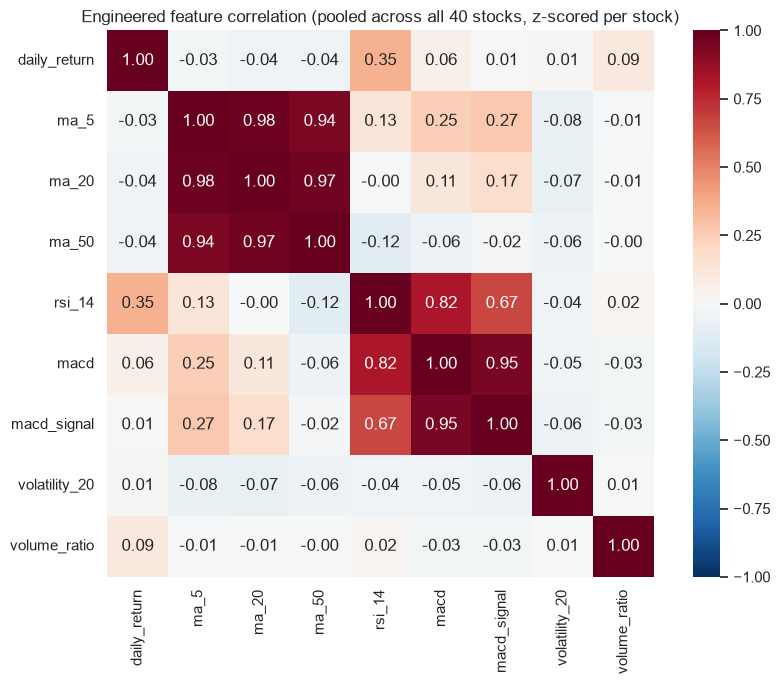

In [5]:
# Pool all stocks' engineered features, z-scoring per stock so scale doesn't
# dominate (e.g. Reliance's absolute MA values vs a lower-priced stock).
pooled = []
for tk, feats in engineered.items():
    z = (feats[FEATURE_COLUMNS] - feats[FEATURE_COLUMNS].mean()) / feats[FEATURE_COLUMNS].std()
    pooled.append(z)
pooled_df = pd.concat(pooled, axis=0)

corr = pooled_df.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Engineered feature correlation (pooled across all 40 stocks, "
             "z-scored per stock)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "features_correlation_heatmap.png", dpi=110)
plt.show()

In [6]:
# Call out the most redundant pairs explicitly.
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
print("Most correlated feature pairs (|r| descending):")
print(pairs.head(8).to_string())
print("\nAs expected, ma_5/ma_20/ma_50 (and macd/macd_signal) are highly "
      "correlated — they're smoothed derivatives of the same price series. "
      "We keep all three MAs anyway: the LSTM can learn to weight short- vs "
      "long-horizon trend differently, and dropping them is a Phase 4+ "
      "decision (e.g. via feature-importance ablation), not a Phase 2 one.")

Most correlated feature pairs (|r| descending):
ma_5          ma_20          0.984226
ma_20         ma_50          0.973879
macd          macd_signal    0.952480
ma_5          ma_50          0.943425
rsi_14        macd           0.815358
              macd_signal    0.671028
daily_return  rsi_14         0.351995
ma_5          macd_signal    0.271023

As expected, ma_5/ma_20/ma_50 (and macd/macd_signal) are highly correlated — they're smoothed derivatives of the same price series. We keep all three MAs anyway: the LSTM can learn to weight short- vs long-horizon trend differently, and dropping them is a Phase 4+ decision (e.g. via feature-importance ablation), not a Phase 2 one.


## 4. Distribution sanity checks — RSI and volatility

`rsi_14` must fall in **[0, 100]** by construction; `volatility_20` (rolling
std of daily returns) should be a small positive number, roughly in the
1-4% daily range for these large-cap names (consistent with the ~20-50%
annualised volatility seen in the Phase 1 EDA).

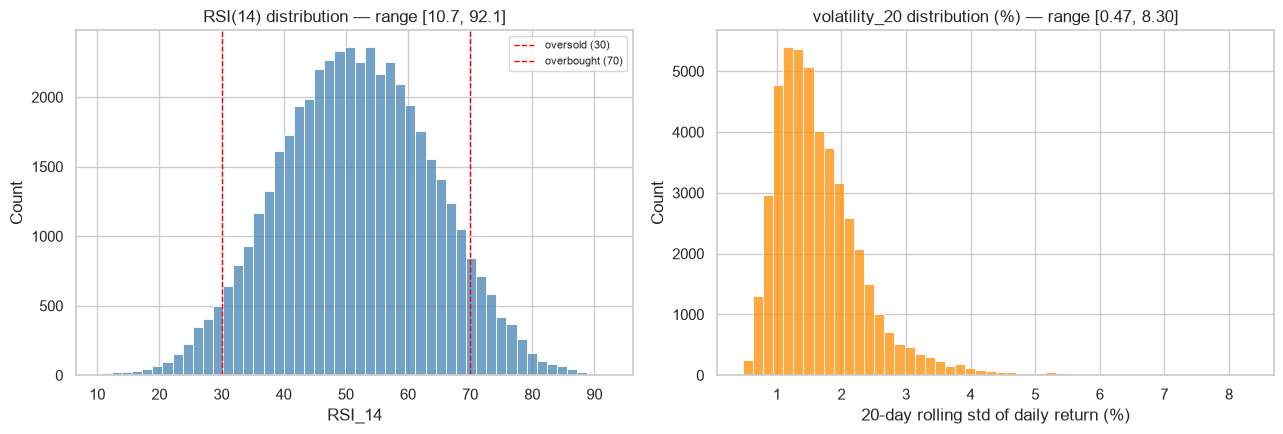


RSI(14) bounds check passed: [10.72, 92.13] within [0, 100].
volatility_20 non-negativity check passed.


In [7]:
all_rsi = pd.concat([f["rsi_14"] for f in engineered.values()])
all_vol = pd.concat([f["volatility_20"] for f in engineered.values()])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(all_rsi, bins=50, ax=axes[0], color="steelblue")
axes[0].axvline(30, color="red", linestyle="--", linewidth=1, label="oversold (30)")
axes[0].axvline(70, color="red", linestyle="--", linewidth=1, label="overbought (70)")
axes[0].set_title(f"RSI(14) distribution — range [{all_rsi.min():.1f}, {all_rsi.max():.1f}]")
axes[0].set_xlabel("RSI_14")
axes[0].legend(fontsize=8)

sns.histplot(all_vol * 100, bins=50, ax=axes[1], color="darkorange")
axes[1].set_title(f"volatility_20 distribution (%) — "
                   f"range [{all_vol.min()*100:.2f}, {all_vol.max()*100:.2f}]")
axes[1].set_xlabel("20-day rolling std of daily return (%)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "features_rsi_volatility_distributions.png", dpi=110)
plt.show()

assert all_rsi.min() >= 0 and all_rsi.max() <= 100, "RSI out of [0, 100] bounds!"
assert (all_vol >= 0).all(), "volatility_20 must be non-negative!"
print(f"\nRSI(14) bounds check passed: [{all_rsi.min():.2f}, {all_rsi.max():.2f}] within [0, 100].")
print(f"volatility_20 non-negativity check passed.")

## 5. Scaling pipeline demonstration

`src.scaling.chronological_split` performs the project's mandatory 70/15/15
**chronological** split (no shuffling), and `scale_features` fits a
`StandardScaler` on **train only**, then applies it to val/test. We demo this
on one representative stock (TCS) and confirm train-set scaled features have
mean ~0 / std ~1, while val/test — scaled with the *train* statistics — do not
(by design; that's the leakage-free behaviour we want).

In [8]:
demo_ticker = "TCS.NS"
feats = engineered[demo_ticker]

train, val, test = chronological_split(feats, train_frac=0.70, val_frac=0.15)
print(f"{demo_ticker}: train={len(train)} rows ({train.index.min().date()} -> "
      f"{train.index.max().date()})")
print(f"{'':>{len(demo_ticker)+2}}val={len(val)} rows ({val.index.min().date()} -> "
      f"{val.index.max().date()})")
print(f"{'':>{len(demo_ticker)+2}}test={len(test)} rows ({test.index.min().date()} -> "
      f"{test.index.max().date()})")

train_s, val_s, test_s, scaler = scale_features(train, val, test, FEATURE_COLUMNS)

print("\nScaled TRAIN feature stats (fit set — mean should be ~0, std ~1):")
print(pd.DataFrame({"mean": train_s[FEATURE_COLUMNS].mean(),
                     "std": train_s[FEATURE_COLUMNS].std()}).round(3))

print("\nScaled TEST feature stats (transformed with TRAIN's mean/std — "
      "mean/std need NOT be 0/1; that would indicate leakage if it were "
      "forced to match):")
print(pd.DataFrame({"mean": test_s[FEATURE_COLUMNS].mean(),
                     "std": test_s[FEATURE_COLUMNS].std()}).round(3))

TCS.NS: train=830 rows (2021-09-24 -> 2025-01-31)
        val=178 rows (2025-02-01 -> 2025-10-21)
        test=179 rows (2025-10-23 -> 2026-07-10)

Scaled TRAIN feature stats (fit set — mean should be ~0, std ~1):
               mean    std
daily_return   -0.0  1.001
ma_5            0.0  1.001
ma_20          -0.0  1.001
ma_50           0.0  1.001
rsi_14         -0.0  1.001
macd           -0.0  1.001
macd_signal     0.0  1.001
volatility_20   0.0  1.001
volume_ratio   -0.0  1.001

Scaled TEST feature stats (transformed with TRAIN's mean/std — mean/std need NOT be 0/1; that would indicate leakage if it were forced to match):
                mean    std
daily_return  -0.152  1.323
ma_5          -1.568  0.934
ma_20         -1.508  0.892
ma_50         -1.376  0.793
rsi_14        -0.582  1.127
macd          -0.859  1.235
macd_signal   -0.917  1.258
volatility_20  0.998  1.804
volume_ratio   0.034  1.099


## 6. Final confirmation — only engineered features reach modeling

**Non-negotiable:** no raw OHLCV column may reach the model. This cell prints
the exact feature list Phase 3/4 will consume and asserts it is disjoint from
the raw OHLCV columns.

In [9]:
print("=" * 60)
print("FEATURES PASSED TO MODELING")
print("=" * 60)
for c in FEATURE_COLUMNS:
    print(f"  - {c}")

overlap = set(FEATURE_COLUMNS) & set(RAW_OHLCV_COLUMNS)
assert not overlap, f"Raw OHLCV column(s) leaked into the feature list: {overlap}"

print(f"\nRaw OHLCV columns (Open/High/Low/Close/Volume) are NOT in this list.")
print(f"'Adj Close' itself is also excluded from modeling features — it is "
      f"kept in the processed CSVs only as the prediction TARGET / for "
      f"plotting, never as an input feature.")
print(f"\nCONFIRMED: {len(FEATURE_COLUMNS)} engineered features, "
      f"0 raw OHLCV columns, will be passed to the models.")

FEATURES PASSED TO MODELING
  - daily_return
  - ma_5
  - ma_20
  - ma_50
  - rsi_14
  - macd
  - macd_signal
  - volatility_20
  - volume_ratio

Raw OHLCV columns (Open/High/Low/Close/Volume) are NOT in this list.
'Adj Close' itself is also excluded from modeling features — it is kept in the processed CSVs only as the prediction TARGET / for plotting, never as an input feature.

CONFIRMED: 9 engineered features, 0 raw OHLCV columns, will be passed to the models.


## Phase 2 takeaways

- **Features:** 9 engineered columns per stock (`daily_return`, `ma_5/20/50`,
  `rsi_14`, `macd`/`macd_signal`, `volatility_20`, `volume_ratio`), computed
  via `pandas_ta` — not hand-rolled formulas.
- **Warm-up:** every stock loses **49-51 rows** to indicator warm-up
  (`MA_50` is the binding constraint), documented per stock above.
- **Redundancy:** `ma_5`/`ma_20`/`ma_50` and `macd`/`macd_signal` are highly
  correlated, as expected for smoothed derivatives of the same series — kept
  for now, revisit via ablation in later phases if needed.
- **Sanity:** RSI stays within [0, 100]; volatility is non-negative and in a
  realistic single-digit-percent daily range.
- **Scaling:** the `chronological_split` + `scale_features` pipeline enforces
  70/15/15 time-ordered splits and a train-only-fit `StandardScaler`.
- **Leakage guard:** confirmed explicitly — only engineered features reach
  modeling; raw OHLCV never does.

**Next (Phase 3):** naive, linear regression, and ARIMA baselines, evaluated
with `RMSE / MAE / MAPE / directional accuracy` on the chronological test
split.